In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
df = pd.read_csv('/kaggle/input/dataset/fully_transformed_student_dataset.csv')

# --- SECTION 1: Handle Missing Values ---

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute Numerical values with Median (robust to outliers)
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Impute Categorical values with Mode (most frequent category)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

# --- SECTION 2: Detect and Treat Outliers (IQR Method) ---

def cap_outliers_iqr(df, column):
    """
    Caps outliers using the IQR method. 
    Instead of removing data (which loses information), we cap it at the bounds.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply to continuous variables where outliers might skew the model
# Note: We are cautious with 'Grades' as 0s might be meaningful (failures), not outliers.
outlier_candidates = ['Age at Enrollment', 'Unemployment Rate (%)', 'GDP per Capita (USD)']

for col in outlier_candidates:
    df = cap_outliers_iqr(df, col)

print(f"Outliers capped for columns: {outlier_candidates}")

# --- SECTION 3: Data Transformation & Feature Extraction ---

# Feature 1: Total Approved Units (combining semesters)
df['Total_Approved_Units'] = df['Approved Units (1st Sem)'] + df['Approved Units (2nd Sem)']

# Feature 2: Approval Rate (Approved / Enrolled)
# We add a small epsilon (1e-9) to avoid division by zero errors
df['Approval_Rate_1st_Sem'] = df['Approved Units (1st Sem)'] / (df['Enrolled Units (1st Sem)'] + 1e-9)
df['Approval_Rate_2nd_Sem'] = df['Approved Units (2nd Sem)'] / (df['Enrolled Units (2nd Sem)'] + 1e-9)

# Feature 3: Grade Evolution (Did they improve in the second semester?)
df['Grade_Improvement'] = df['Average Grade (2nd Sem)'] - df['Average Grade (1st Sem)']

# --- SECTION 4: Normalization/Standardization ---
# We use StandardScaler for algorithms that assume normally distributed data (like SVM, Logistic Regression)

scaler = StandardScaler()

# List of columns to normalize (exclude target variable and new categorical features)
cols_to_scale = [
    'Age at Enrollment', 
    'GDP per Capita (USD)', 
    'Unemployment Rate (%)', 
    'Total_Approved_Units',
    'Grade_Improvement'
]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Final Inspection
print("\nTransformation Complete. New Data Head:")
print(df[['Age at Enrollment', 'Total_Approved_Units', 'Grade_Improvement']].head())

# Save the processed file (Optional)
df.to_csv('/kaggle/working/processed_student_data.csv', index=False)

Missing values handled.
Outliers capped for columns: ['Age at Enrollment', 'Unemployment Rate (%)', 'GDP per Capita (USD)']

Transformation Complete. New Data Head:
   Age at Enrollment  Total_Approved_Units  Grade_Improvement
0          -0.454236             -1.533977           0.142079
1          -0.639106              0.479467           0.026741
2          -0.639106             -1.533977           0.142079
3          -0.454236              0.311680          -0.213822
4           2.133947              0.311680           0.372756


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


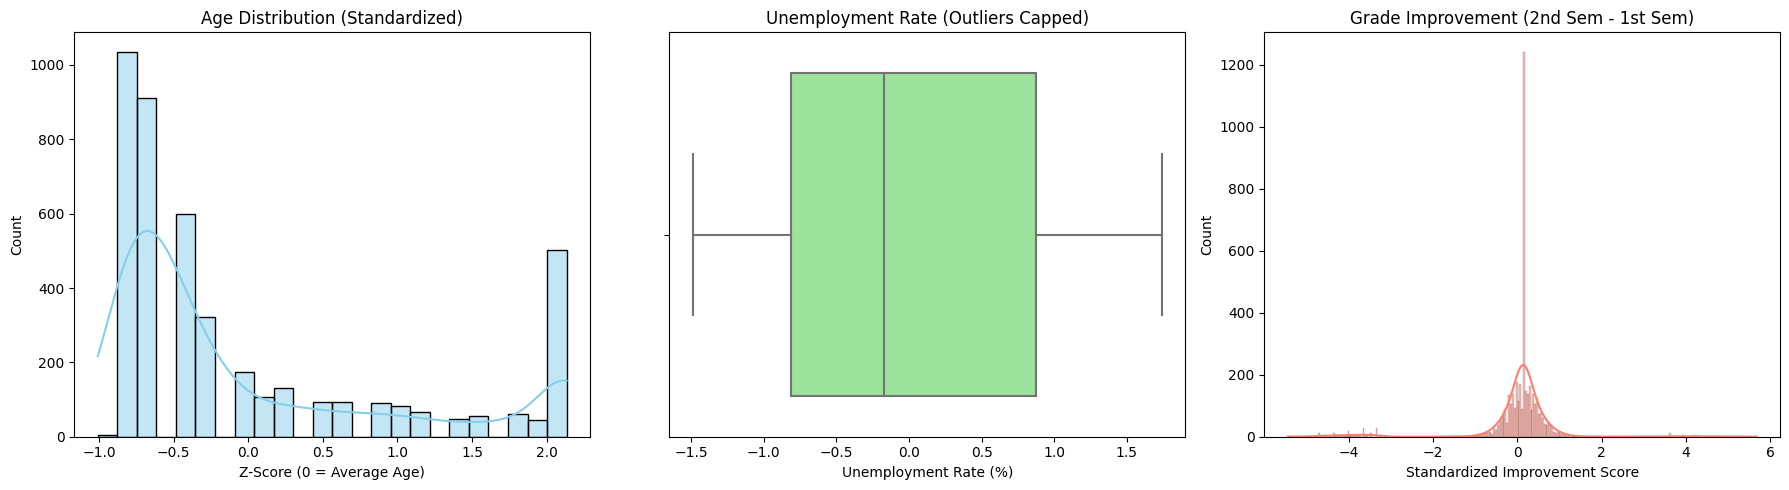

Processed data saved as 'processed_student_data.csv'


In [3]:
# --- SECTION 5: Visualize the Transformations (Sanity Check) ---

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Age Distribution (After Scaling)
sns.histplot(df['Age at Enrollment'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution (Standardized)')
axes[0].set_xlabel('Z-Score (0 = Average Age)')

# Plot 2: Outlier Check for Unemployment Rate
sns.boxplot(x=df['Unemployment Rate (%)'], ax=axes[1], color='lightgreen')
axes[1].set_title('Unemployment Rate (Outliers Capped)')

# Plot 3: New Feature - Grade Improvement
sns.histplot(df['Grade_Improvement'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Grade Improvement (2nd Sem - 1st Sem)')
axes[2].set_xlabel('Standardized Improvement Score')

plt.tight_layout()
plt.show()

# --- SECTION 6: Save Final Data for Modeling ---
# This saves the clean data so you can load it in a different notebook or section
df.to_csv('/kaggle/working/processed_student_data.csv', index=False)
print("Processed data saved as 'processed_student_data.csv'")

Original shape: (4424, 39)
Shape after dropping 'Enrolled': (3630, 39)


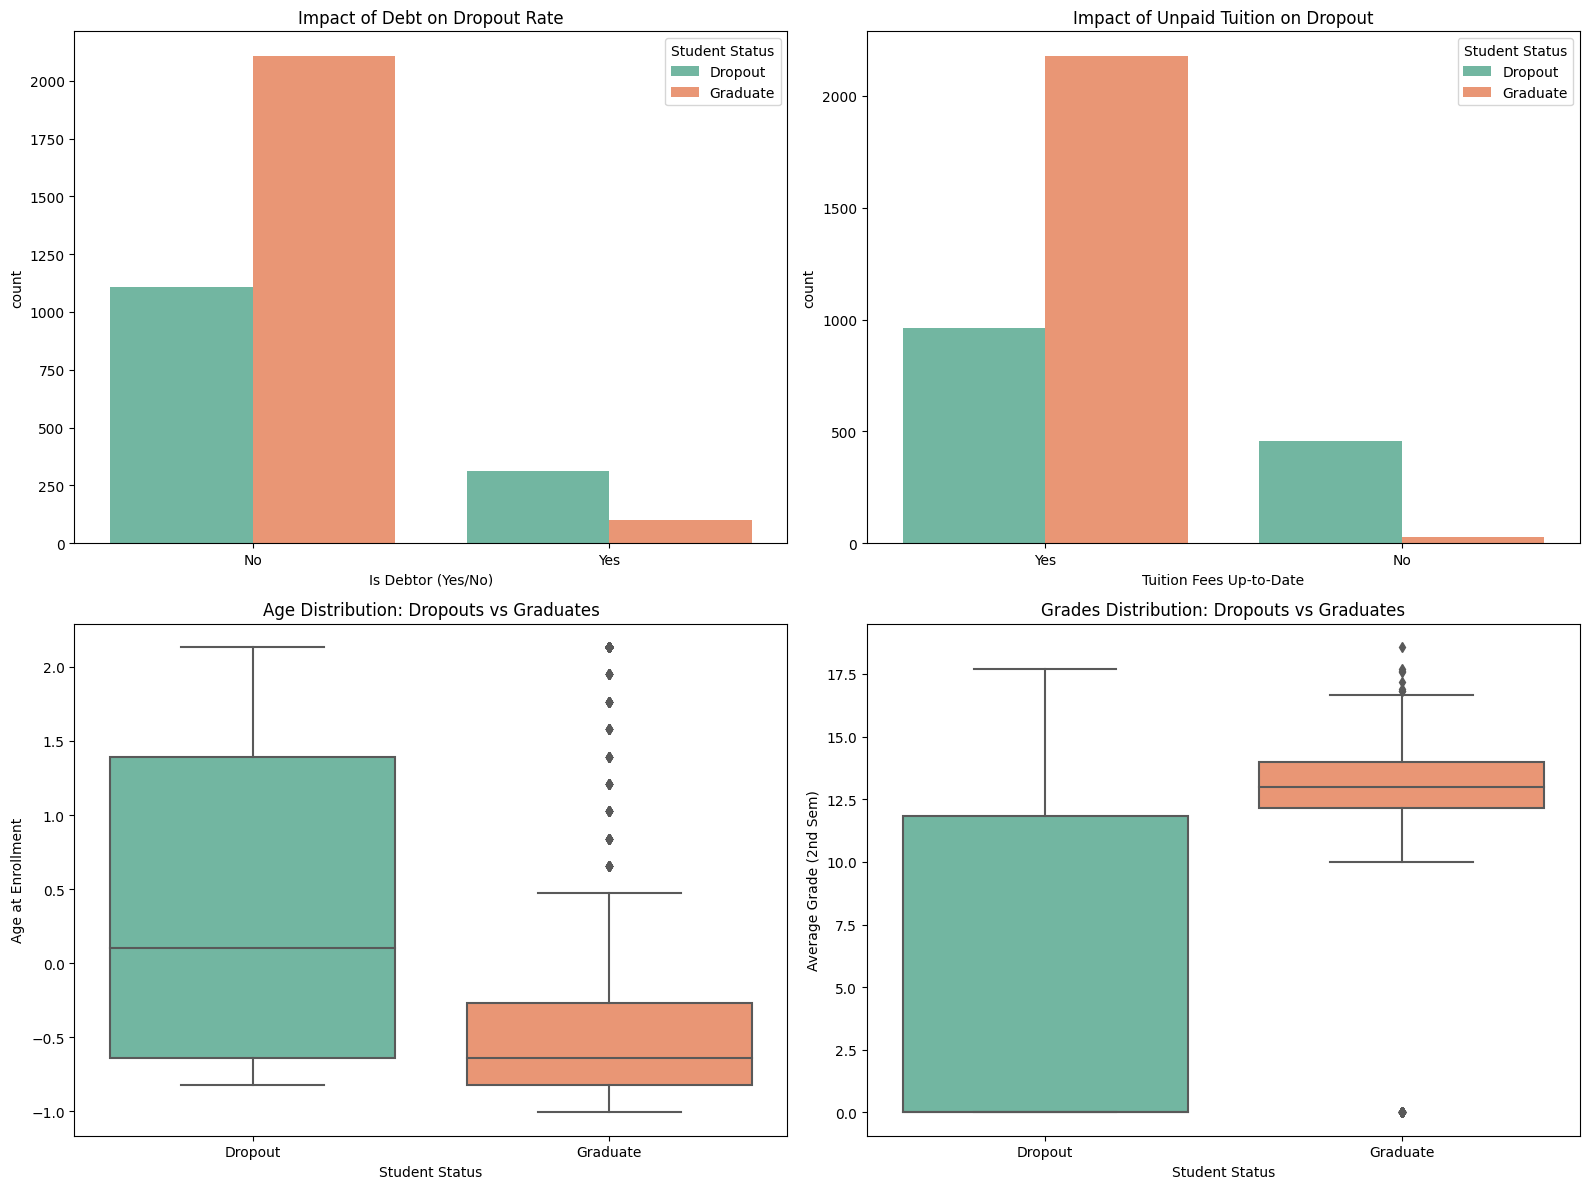


Top 5 Features positively correlated with Dropout:
Is_Dropout                       1.000000
Age at Enrollment                0.312803
Not Evaluated Units (2nd Sem)    0.102687
Not Evaluated Units (1st Sem)    0.074642
Inflation Rate (%)               0.030326
Unemployment Rate (%)           -0.004198
Name: Is_Dropout, dtype: float64

Top 5 Features negatively correlated with Dropout (Protective factors):
Approval_Rate_2nd_Sem      -0.740123
Approval_Rate_1st_Sem      -0.670238
Approved Units (2nd Sem)   -0.653995
Total_Approved_Units       -0.616893
Average Grade (2nd Sem)    -0.605350
Name: Is_Dropout, dtype: float64


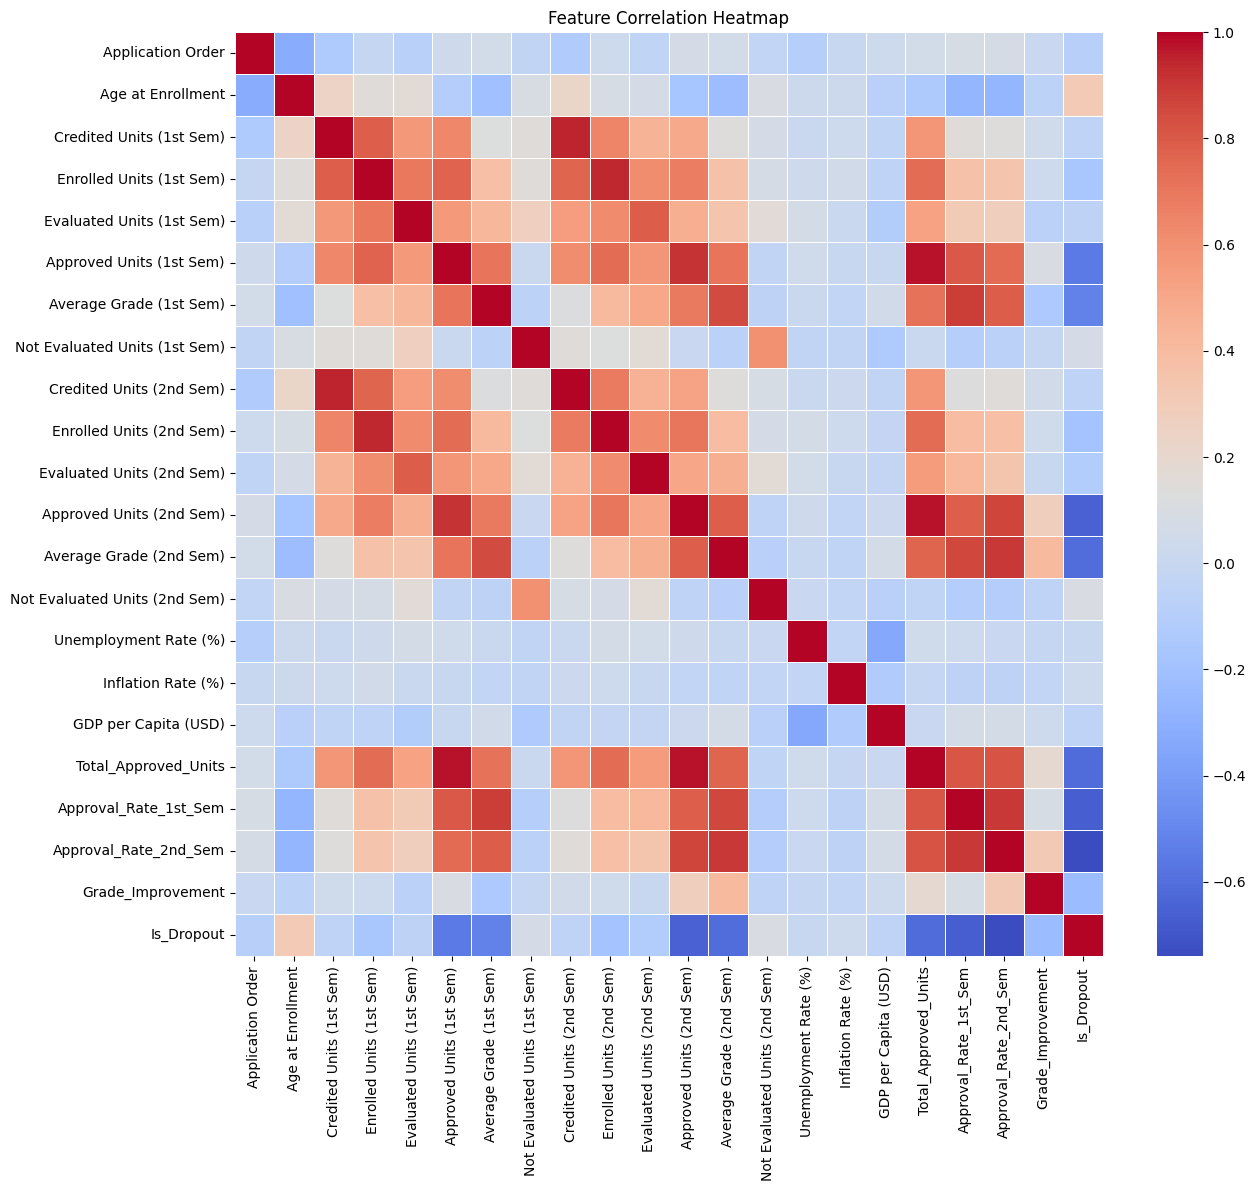

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Use the dataframe from the previous step (df)
# If you need to reload it:
# df = pd.read_csv('fully_transformed_student_dataset.csv') # or 'processed_student_data.csv'

# --- SECTION 1: Drop Rows (Justification & Execution) ---
print(f"Original shape: {df.shape}")

# JUSTIFICATION: 
# We remove rows where Student Status is 'Enrolled'. 
# These students are currently mid-study. Including them muddies the analysis 
# of what factors lead to 'Dropout' vs 'Graduate'. 
# We want to train on completed outcomes only.
df_analysis = df[df['Student Status'] != 'Enrolled'].copy()

print(f"Shape after dropping 'Enrolled': {df_analysis.shape}")

# Encode Target for Correlation: Dropout=1, Graduate=0
df_analysis['Is_Dropout'] = df_analysis['Student Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# --- SECTION 2: Impact on Dropout (Visual Comparisons) ---

# Set up visualization grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Economic Impact: Debtor Status
sns.countplot(data=df_analysis, x='Is Debtor', hue='Student Status', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Impact of Debt on Dropout Rate')
axes[0, 0].set_xlabel('Is Debtor (Yes/No)')

# 2. Academic Impact: Tuition Fees Up-to-Date
# This is often a strong predictor; students not paying often drop out.
sns.countplot(data=df_analysis, x='Tuition Fees Up-to-Date', hue='Student Status', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Impact of Unpaid Tuition on Dropout')

# 3. Demographic Impact: Age (Boxplot to show distribution)
sns.boxplot(data=df_analysis, x='Student Status', y='Age at Enrollment', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Age Distribution: Dropouts vs Graduates')

# 4. Performance Impact: 2nd Semester Grades
sns.boxplot(data=df_analysis, x='Student Status', y='Average Grade (2nd Sem)', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Grades Distribution: Dropouts vs Graduates')

plt.tight_layout()
plt.show()

# --- SECTION 3: Correlation Analysis ---

# Select only numerical columns for correlation
numerical_cols = df_analysis.select_dtypes(include=['int64', 'float64']).columns

# Calculate Correlation Matrix
corr_matrix = df_analysis[numerical_cols].corr()

# Check correlation with the Target (Is_Dropout)
print("\nTop 5 Features positively correlated with Dropout:")
print(corr_matrix['Is_Dropout'].sort_values(ascending=False).head(6))

print("\nTop 5 Features negatively correlated with Dropout (Protective factors):")
print(corr_matrix['Is_Dropout'].sort_values(ascending=True).head(5))

# Plot Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import pickle
import time

# --- 1. Load & Prepare Data ---
df = pd.read_csv('processed_student_data.csv')

# Select features
selected_features = [
    'Tuition Fees Up-to-Date', 'Is Debtor', 'Gender (1=Male, 0=Female)', 
    'Scholarship Holder', 'Age at Enrollment', 'Average Grade (2nd Sem)', 
    'Approved Units (1st Sem)'
]

# --- FIX: Map ALL text columns to numbers ---
# 1. Map Yes/No columns
binary_cols = ['Tuition Fees Up-to-Date', 'Is Debtor', 'Scholarship Holder']
for col in binary_cols:
    if col in df.columns:
        # Check if it's string type before mapping to avoid errors if already mapped
        if df[col].dtype == 'object':
             df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. Map Gender column (Male=1, Female=0)
gender_col = 'Gender (1=Male, 0=Female)'
if gender_col in df.columns:
     if df[gender_col].dtype == 'object':
        df[gender_col] = df[gender_col].map({'Male': 1, 'Female': 0})

# Select X and y
X = df[selected_features]
y = df['Student Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# --- 2. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Hyperparameter Tuning ---
param_grid = {
    'n_estimators': [50, 100],      
    'max_depth': [10, 20, None]     
}

rf = RandomForestClassifier(random_state=42)

print("Initializing Grid Search...")
# n_jobs=-1 uses all processors
grid_search = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=3)

start_time = time.time()
print(f"Starting training on {len(X_train)} samples...")

# TRAIN
grid_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\nTraining Complete in {elapsed_time:.2f} seconds!")
print(f"Best Params: {grid_search.best_params_}")

# --- 4. Evaluation ---
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Save Model ---
with open('student_dropout_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved as 'student_dropout_model.pkl'")

Initializing Grid Search...
Starting training on 3539 samples...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Training Complete in 1.31 seconds!
Best Params: {'max_depth': 10, 'n_estimators': 100}

Accuracy: 0.8328
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       569
           1       0.84      0.65      0.74       316

    accuracy                           0.83       885
   macro avg       0.84      0.79      0.81       885
weighted avg       0.83      0.83      0.83       885

Model saved as 'student_dropout_model.pkl'
[CV 1/3] END ......max_depth=10, n_estimators=100;, score=nan total time=   0.0s
[CV 1/3] END ....max_depth=10, n_estimators=100;, score=0.850 total time=   0.3s
[CV 2/3] END .....max_depth=20, n_estimators=50;, score=0.843 total time=   0.2s
[CV 3/3] END ...max_depth=None, n_estimators=50;, score=0.852 total time=   0.2s
[CV 1/3] END ..max_depth=None, n_estimators=100;, sc